# 03. Modeling — Batch 1 학습, Batch 2 평가

**목적**
- DAY 1에 정한 전략대로 모델을 만든다: 타깃 `log10(cycle_life)`, 핵심 피처 `log_var`, 선형 계열 모델.
- 모델 선택은 Batch 1 안에서만 한다. Batch 2는 모델을 확정한 뒤 한 번만 평가한다.

## 환경 설정

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('..')   # 저장소 최상위를 경로에 추가
from src.preprocess import load_cache
from src.features import build_features

warnings.filterwarnings('ignore')

# 재현성
SEED = 42
np.random.seed(SEED)

# 경로
PROC_DIR = '../data/processed'
FIG_DIR = '../results/figures'
RESULT_DIR = '../results'

# 그래프 설정 (한글 폰트 포함)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

## 1. 피처 표 만들기

**목적**: `src`의 파이프라인으로 119셀의 피처 표를 만들고, 학습 배치(Batch 1)와 평가 배치를 나눈다.

In [2]:
df, qdlin, vdlin = load_cache(PROC_DIR)
feat = build_features(df, qdlin)

b1 = feat[feat['batch'] == 1].reset_index(drop=True)   # 학습 배치
b2 = feat[feat['batch'] == 2].reset_index(drop=True)   # 평가 배치
b3 = feat[feat['batch'] == 3].reset_index(drop=True)   # 추가 평가 배치

print(feat.shape)
print(feat.groupby('group').size())

(119, 10)
group
Batch 1                 36
Batch 2 newstructure     9
Batch 2 일반              30
Batch 3                 44
dtype: int64


## 2. 데이터 분할

**목적**: Batch 1의 36셀을 Train과 Hold-out(Valid)으로 나눈다.

**규칙**
- **충전 정책 단위로 나눈다.** Batch 1은 정책 20가지에 정책당 1~2셀이다. 같은 정책의 두 셀이 양쪽에 나뉘면, 거의 같은 셀을 보고 맞히는 셈이 되어 검증 성능이 실제보다 좋게 나온다.
- **수명 구간별로 고르게 뽑는다.** 정책을 평균 수명 순으로 정렬해 4개마다 하나씩 Hold-out으로 보낸다. 36셀에서 무작위로 뽑으면 수명이 한쪽으로 쏠릴 수 있다.
- **수명이 가장 짧은 정책과 가장 긴 정책은 Train에 남긴다.** 정렬한 순서에서 3번째부터 뽑는다. Hold-out은 학습 범위 안의 예측을 확인하는 용도이고, 범위 밖 예측은 뒤의 외삽 점검에서 따로 확인한다.

**기대하는 결과**: Hold-out이 정책 5개, 약 9셀(25%).

In [3]:
HOLDOUT_EVERY = 4   # 정책 4개마다 하나를 Hold-out으로
HOLDOUT_START = 2   # 평균 수명 순으로 3번째 정책부터 (0부터 세어 2)


def split_by_policy(data):
    """충전 정책 단위로 Train / Hold-out을 나눈다. 정책을 평균 수명 순으로 정렬해 일정 간격으로 뽑는다."""
    order = data.groupby('policy')['cycle_life'].mean().sort_values().index
    hold_policies = set(order[HOLDOUT_START::HOLDOUT_EVERY])
    is_hold = data['policy'].isin(hold_policies)
    return data[~is_hold].reset_index(drop=True), data[is_hold].reset_index(drop=True)


train, valid = split_by_policy(b1)

print('Train:', len(train), '셀,', train['policy'].nunique(), '정책')
print('Valid:', len(valid), '셀,', valid['policy'].nunique(), '정책')
print('양쪽에 모두 있는 정책:', len(set(train['policy']) & set(valid['policy'])))
print()
print(pd.DataFrame({'Train': train['cycle_life'].describe(),
                    'Valid': valid['cycle_life'].describe()}).round(1))
print()
print('Hold-out 셀')
print(valid.sort_values('cycle_life')[['cell_id', 'policy', 'cycle_life']].to_string(index=False))

Train: 27 셀, 15 정책
Valid: 9 셀, 5 정책
양쪽에 모두 있는 정책: 0

        Train   Valid
count    27.0     9.0
mean    786.9   793.0
std     152.2   146.4
min     534.0   617.0
25%     676.5   691.0
50%     757.0   788.0
75%     870.0   876.0
max    1074.0  1054.0

Hold-out 셀
cell_id         policy  cycle_life
  b1c38   7C(40%)-3.6C       617.0
  b1c39   7C(40%)-3.6C       625.0
  b1c18   5.4C(70%)-3C       691.0
  b1c30   6C(50%)-3.6C       709.0
  b1c19   5.4C(70%)-3C       788.0
  b1c28     6C(50%)-3C       860.0
  b1c31   6C(50%)-3.6C       876.0
  b1c29     6C(50%)-3C       917.0
   b1c9 5.4C(40%)-3.6C      1054.0


**결과 해석 — 데이터 분할**

- Train 27셀(정책 15개), Hold-out 9셀(정책 5개)로 나뉘었다. Hold-out 비율은 25%다.
- 같은 정책이 양쪽에 있는 경우가 없다. 정책 단위 분할이 의도대로 적용됐다.
- 두 집합의 수명 분포가 비슷하다. 평균 786.9 / 793.0, 중앙값 757 / 788, 표준편차 152.2 / 146.4다.
- Train의 수명 범위(534~1,074)가 Batch 1 전체와 같다. Hold-out(617~1,054)은 전부 그 안에 있으므로, Hold-out 성능은 학습 범위 안의 예측 성능이다.
- Hold-out에 b1c18이 포함됐다. EDA(Q5-1)에서 초기 측정이 불안정했던 셀이다. 규칙대로 뽑힌 결과이므로 그대로 두고, Hold-out 평가에서 이 셀의 오차를 따로 확인한다.

## 3. 모델 비교 (Train 27셀, 교차검증)

**목적**: 피처 구성 2가지와 모델 3가지를 비교해 하나를 고른다.

| 구분 | 내용 |
|---|---|
| 피처 구성 | ① `log_var` ② `log_var` + `qd_slope_last` |
| 모델 | 선형 회귀, Ridge, LASSO |
| 검증 | 정책 단위 GroupKFold(5). 같은 정책의 셀은 같은 폴드에 둔다. |
| 지표 | MAPE. 예측한 `log10(수명)`을 원래 단위로 되돌린 뒤 계산한다. |

**규칙**
- 표준화는 각 폴드의 학습 부분에서만 fit한다. 파이프라인으로 묶어 처리한다.
- Ridge와 LASSO의 `alpha`는 로그 스케일로 11개 값을 탐색해 검증 MAPE가 가장 낮은 값을 쓴다.
- 검증 MAPE의 차이가 작으면 더 단순한 쪽(피처 1개, 선형 회귀)을 고른다.

In [4]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold

N_SPLITS = 5
ALPHAS = np.logspace(-4, 1, 11)   # 0.0001 ~ 10
FEATURE_SETS = {
    'log_var': ['log_var'],
    'log_var + qd_slope_last': ['log_var', 'qd_slope_last'],
}


def mape(y_true_log, y_pred_log):
    """로그 타깃을 원래 단위(사이클)로 되돌린 뒤 MAPE(%)를 계산한다."""
    y, p = 10 ** np.asarray(y_true_log), 10 ** np.asarray(y_pred_log)
    return np.mean(np.abs(p - y) / y) * 100


def make_model(name, alpha=None):
    """표준화와 회귀 모델을 묶은 파이프라인을 만든다."""
    if name == 'Linear':
        reg = LinearRegression()
    elif name == 'Ridge':
        reg = Ridge(alpha=alpha)
    else:
        reg = Lasso(alpha=alpha, max_iter=100000)
    return make_pipeline(StandardScaler(), reg)


def cv_mape(data, cols, name, alpha=None):
    """정책 단위 GroupKFold로 학습 폴드 MAPE, 검증 폴드 MAPE의 평균과 표준편차를 구한다."""
    X, y, g = data[cols].values, data['log_life'].values, data['policy'].values
    tr_scores, va_scores = [], []
    for tr, va in GroupKFold(n_splits=N_SPLITS).split(X, y, g):
        m = make_model(name, alpha).fit(X[tr], y[tr])
        tr_scores.append(mape(y[tr], m.predict(X[tr])))
        va_scores.append(mape(y[va], m.predict(X[va])))
    return np.mean(tr_scores), np.mean(va_scores), np.std(va_scores)


rows = []
for fs, cols in FEATURE_SETS.items():
    for name in ['Linear', 'Ridge', 'LASSO']:
        cands = [None] if name == 'Linear' else ALPHAS
        res = [(a,) + cv_mape(train, cols, name, a) for a in cands]
        a, tr, va, sd = min(res, key=lambda r: r[2])   # 검증 MAPE가 가장 낮은 alpha
        rows.append({'피처': fs, '모델': name, 'alpha': a,
                     '학습 폴드 MAPE': tr, '검증 폴드 MAPE': va, '폴드 간 표준편차': sd})

cv_table = pd.DataFrame(rows)
print(cv_table.round(3).to_string(index=False))

                     피처     모델  alpha  학습 폴드 MAPE  검증 폴드 MAPE  폴드 간 표준편차
                log_var Linear    NaN       7.830       9.463      1.910
                log_var  Ridge  0.000       7.830       9.463      1.910
                log_var  LASSO  0.000       7.830       9.465      1.918
log_var + qd_slope_last Linear    NaN       7.661      10.188      1.806
log_var + qd_slope_last  Ridge  3.162       7.918       9.510      3.228
log_var + qd_slope_last  LASSO  0.003       7.743       9.642      2.272


**결과 해석 — 모델 비교**

- **`log_var` 하나를 쓰는 선형 회귀를 선택한다.** 검증 폴드 MAPE가 9.46%로 여섯 조합 중 가장 낮고, 가장 단순하다.
- **두 번째 피처 `qd_slope_last`는 추가하지 않는다.** 선형 회귀에 넣으면 학습 폴드 MAPE는 7.83 → 7.66으로 내려가지만 검증 폴드는 9.46 → 10.19로 올라간다. 학습 데이터에만 맞춰지는 과적합이다.
- 정규화로도 나아지지 않는다. 피처 2개에서 Ridge(`alpha` 3.16)는 9.51%, LASSO는 9.64%로 피처 1개의 결과를 넘지 못한다.
- 피처 1개에서는 Ridge와 LASSO가 탐색 범위의 가장 작은 `alpha`(0.0001)를 골랐고 결과가 선형 회귀와 같다. 정규화가 필요하지 않다.
- 여섯 조합의 차이(9.46~10.19)는 폴드 간 표준편차(1.8~3.2)보다 작다. 조합 간 우열을 확정할 수는 없으므로, 미리 정한 규칙(차이가 작으면 단순한 모델)에 따라 골랐다.
- 선택한 모델의 학습 폴드 MAPE는 7.83%, 검증 폴드 MAPE는 9.46%다. 성능 표의 Train (CV) 값은 9.46%다.

## 4. 외삽 점검 — 학습 범위 밖을 예측할 수 있는가

**목적**: Batch 2 일반 30셀은 전부 Batch 1의 최소 수명보다 짧다. 같은 상황을 Train 안에서 미리 만들어, 선형 모델과 트리 계열이 학습 범위 밖을 어떻게 예측하는지 비교한다.

**방법**
- Train 27셀에서 수명이 짧은 7셀(약 25%)을 뺀다.
- 남은 20셀로 학습하고 뺀 7셀을 예측한다.
- 선형 회귀, Random Forest, XGBoost를 같은 피처(`log_var`)로 비교한다.

**확인하려는 가설 (DAY 1)**: 트리 계열은 학습 타깃의 범위 밖 값을 출력할 수 없으므로, 뺀 셀의 수명을 학습 범위의 최솟값 이상으로만 예측할 것이다.

Random Forest와 XGBoost는 이 점검의 대조군이며 최종 모델 후보가 아니다. Hold-out은 이 단계에서 쓰지 않는다.

In [5]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

N_OUT = 7            # 뺄 셀 수 (수명이 짧은 순)
cols = ['log_var']

s = train.sort_values('cycle_life').reset_index(drop=True)
out, rest = s.iloc[:N_OUT], s.iloc[N_OUT:]

print('뺀 셀의 수명:', out['cycle_life'].astype(int).tolist())
print('남긴 셀의 수명 범위:', int(rest['cycle_life'].min()), '~', int(rest['cycle_life'].max()))
print('log_var 범위 — 뺀 셀:', out['log_var'].min().round(2), '~', out['log_var'].max().round(2),
      '/ 남긴 셀:', rest['log_var'].min().round(2), '~', rest['log_var'].max().round(2))
print()

models = {
    '선형 회귀': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=SEED),
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=SEED),
}

rows, preds = [], {}
for name, m in models.items():
    m.fit(rest[cols].values, rest['log_life'].values)
    p = m.predict(out[cols].values)
    preds[name] = 10 ** p
    rows.append({'모델': name,
                 '남긴 셀 MAPE': mape(rest['log_life'], m.predict(rest[cols].values)),
                 '뺀 셀 MAPE': mape(out['log_life'], p),
                 '뺀 셀 예측 최소': 10 ** p.min(),
                 '뺀 셀 예측 최대': 10 ** p.max(),
                 '평균 편향(%)': (np.mean(10 ** p / out['cycle_life'].values) - 1) * 100})

extrap = pd.DataFrame(rows)
print(extrap.round(1).to_string(index=False))

뺀 셀의 수명: [534, 559, 599, 616, 636, 648, 651]
남긴 셀의 수명 범위: 702 ~ 1074
log_var 범위 — 뺀 셀: -3.77 ~ -3.34 / 남긴 셀: -4.16 ~ -3.65



           모델  남긴 셀 MAPE  뺀 셀 MAPE  뺀 셀 예측 최소  뺀 셀 예측 최대  평균 편향(%)
        선형 회귀        8.4      12.4      615.3      779.2      12.4
Random Forest        4.3      22.6      715.4      823.8      22.6
      XGBoost        0.7      24.9      730.7      862.9      24.9


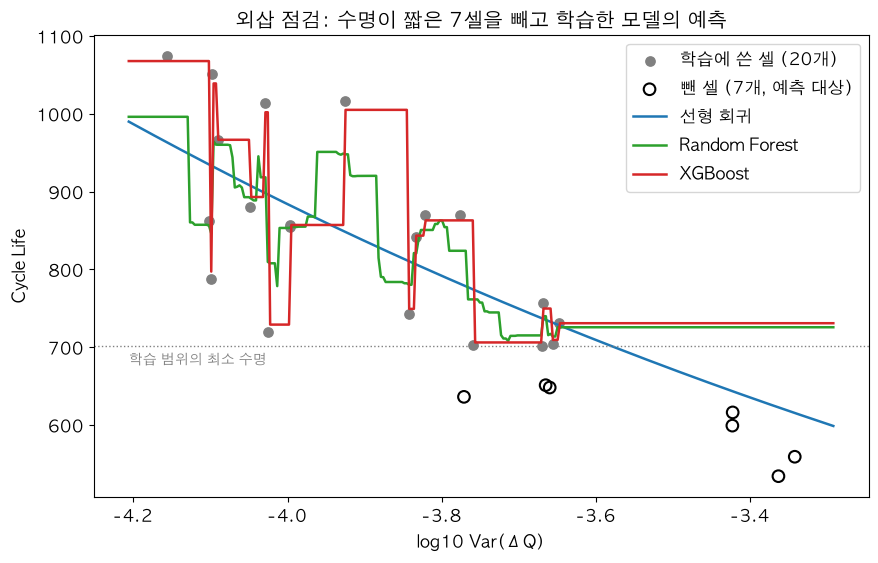

In [6]:
grid = np.linspace(train['log_var'].min() - 0.05, train['log_var'].max() + 0.05, 300).reshape(-1, 1)
line_colors = {'선형 회귀': 'tab:blue', 'Random Forest': 'tab:green', 'XGBoost': 'tab:red'}

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(rest['log_var'], rest['cycle_life'], color='gray', s=45, label=f'학습에 쓴 셀 ({len(rest)}개)')
ax.scatter(out['log_var'], out['cycle_life'], facecolors='none', edgecolors='black', s=70,
           linewidths=1.5, label=f'뺀 셀 ({len(out)}개, 예측 대상)')
for name, m in models.items():
    ax.plot(grid, 10 ** m.predict(grid), color=line_colors[name], linewidth=1.8, label=name)
ax.axhline(rest['cycle_life'].min(), color='gray', linestyle=':', linewidth=1)
ax.text(grid.min(), rest['cycle_life'].min() - 8, '학습 범위의 최소 수명', va='top', fontsize=10, color='gray')
ax.set_xlabel('log10 Var(ΔQ)')
ax.set_ylabel('Cycle Life')
ax.set_title('외삽 점검: 수명이 짧은 7셀을 빼고 학습한 모델의 예측')
ax.legend()
plt.savefig(os.path.join(FIG_DIR, 'm1_extrapolation.png'), dpi=150, bbox_inches='tight')
plt.show()

**결과 해석 — 외삽 점검**

- **DAY 1의 가설이 확인됐다. 트리 계열은 학습 범위 밖을 예측하지 못한다.** 남긴 셀의 최소 수명이 702인데, 뺀 7셀(534~651)에 대한 예측 최소가 Random Forest 715, XGBoost 731이다. 그림에서 두 모델의 예측선은 학습 데이터가 끝나는 지점부터 수평이다.
- **선형 회귀는 범위 밖으로 연장된다.** 예측 최소가 615로 학습 범위보다 아래이고, 뺀 셀 MAPE가 12.4%로 트리 계열(22.6%, 24.9%)의 절반 수준이다.
- **학습 데이터에 잘 맞는 것과 범위 밖을 맞히는 것은 별개다.** 남긴 셀 MAPE는 XGBoost 0.7%, Random Forest 4.3%, 선형 회귀 8.4%로 순서가 반대다. 그림에서 트리 계열의 예측선은 학습 점을 하나하나 따라간다.
- 선형 회귀도 7셀을 모두 과대예측했다(+12.4%). 뺀 셀을 수명이 짧은 순으로 골랐기 때문에, 같은 `log_var`에서 직선보다 아래에 있는 셀이 뽑혀 어떤 모델이든 과대예측 쪽으로 치우친다. 뺀 셀 중 3개는 `log_var`가 학습 범위 안에 있다. 따라서 12.4%는 실제 외삽 오차보다 크게 나온 값이고, 이 점검에서 읽을 것은 모델 간의 비교다.
- **결론**: 평가 배치의 다수가 학습 범위 밖에 있는 이 과제에서는 선형 모델을 써야 한다. 3단계에서 고른 `log_var` 선형 회귀를 최종 모델로 확정한다.

## 5. Hold-out 평가

**목적**: 확정한 모델(`log_var` 선형 회귀)을 Train 27셀 전체로 학습하고, 지금까지 한 번도 쓰지 않은 Hold-out 9셀로 성능을 확인한다.

**보는 지표**
- **MAPE**: 과제 지정 지표.
- **편향**: 집단 전체가 한쪽으로 치우친 정도. 로그 잔차(예측 − 실제)의 평균을 비율로 환산한다. 양수이면 과대예측이다.
- **편향 제거 후 MAPE**: 예측에서 편향을 뺀 뒤의 MAPE. 치우침을 빼고 남는 셀별 오차다.

Hold-out은 모델 선택에 쓰지 않았으므로, 이 결과를 보고 모델을 바꾸지 않는다.

In [7]:
FINAL_COLS = ['log_var']
final = make_model('Linear').fit(train[FINAL_COLS].values, train['log_life'].values)

# 표준화를 풀어 원래 단위의 직선으로 표시
sc, reg = final.named_steps['standardscaler'], final.named_steps['linearregression']
slope = reg.coef_[0] / sc.scale_[0]
intercept = reg.intercept_ - slope * sc.mean_[0]
print(f'최종 모델: log_life = {slope:.3f} * log_var + {intercept:.3f}')
print()


def evaluate(data, model, cols):
    """예측을 붙이고 MAPE, 편향, 편향 제거 후 MAPE를 계산한다."""
    r = data[['cell_id', 'group', 'policy', 'cycle_life', 'log_life']].copy()
    r['pred_log'] = model.predict(data[cols].values)
    r['pred'] = 10 ** r['pred_log']
    r['err_pct'] = (r['pred'] / r['cycle_life'] - 1) * 100       # 양수이면 과대예측
    resid = r['pred_log'] - r['log_life']
    summary = {
        '셀': len(r),
        'MAPE': mape(r['log_life'], r['pred_log']),
        '편향(%)': (10 ** resid.mean() - 1) * 100,
        '편향 제거 후 MAPE': mape(r['log_life'], r['pred_log'] - resid.mean()),
    }
    return r, summary


res_train, sum_train = evaluate(train, final, FINAL_COLS)
res_valid, sum_valid = evaluate(valid, final, FINAL_COLS)

print(pd.DataFrame({'Train (27셀, 학습에 쓴 데이터)': sum_train,
                    'Valid (Hold-out 9셀)': sum_valid}).round(2))
print()
print('Hold-out 셀별 예측')
print(res_valid.sort_values('cycle_life')[['cell_id', 'policy', 'cycle_life', 'pred', 'err_pct']]
      .round(1).to_string(index=False))

최종 모델: log_life = -0.296 * log_var + 1.760

              Train (27셀, 학습에 쓴 데이터)  Valid (Hold-out 9셀)
셀                               27.0                 9.00
MAPE                             8.0                 8.71
편향(%)                            0.0                -7.65
편향 제거 후 MAPE                     8.0                 7.74

Hold-out 셀별 예측
cell_id         policy  cycle_life  pred  err_pct
  b1c38   7C(40%)-3.6C       617.0 597.4     -3.2
  b1c39   7C(40%)-3.6C       625.0 628.5      0.6
  b1c18   5.4C(70%)-3C       691.0 699.2      1.2
  b1c30   6C(50%)-3.6C       709.0 740.5      4.4
  b1c19   5.4C(70%)-3C       788.0 685.2    -13.0
  b1c28     6C(50%)-3C       860.0 782.5     -9.0
  b1c31   6C(50%)-3.6C       876.0 751.4    -14.2
  b1c29     6C(50%)-3C       917.0 780.2    -14.9
   b1c9 5.4C(40%)-3.6C      1054.0 866.4    -17.8


**결과 해석 — Hold-out 평가**

- 최종 모델은 `log_life = −0.296 × log_var + 1.760`이다. EDA에서 Batch 1 36셀로 구한 직선(−0.300, 1.752)과 거의 같다. 학습 셀을 27개로 줄여도 관계가 유지된다.
- **Hold-out MAPE는 8.71%다.** 교차검증의 9.46%와 0.75%p 차이이고, 폴드 간 표준편차(1.9) 안에 있다. 과적합의 신호는 없다.
- **수명이 긴 셀을 과소예측한다.** 수명 709 이하인 4셀의 오차는 −3.2~+4.4%이지만, 788 이상인 5셀은 전부 −9~−18%다. Hold-out의 편향 −7.65%는 이 5셀에서 나온다.
- 이 패턴은 9셀에서 관찰한 것이어서 모델의 성질이라고 단정하지 않는다. 수명이 더 긴 Batch 3에 적용할 때 같은 방향의 오차가 나오는지 확인한다.
- b1c18의 오차는 +1.2%다. EDA(Q5-1)에서 초기 측정이 불안정했던 셀이지만 ΔQ 피처에는 영향이 없었다.
- 성능 표의 값: Train (CV) 9.46%, Valid (Hold-out) 8.71%, Gap (Train − Valid) +0.75%p.

## 6. Test 평가 — Batch 2

**목적**: 확정한 모델을 평가 배치에 한 번 적용한다. 모델은 5단계에서 Train 27셀로 학습한 것을 그대로 쓴다.

**DAY 1에 예상한 것**
- Batch 2 일반 30셀에서 약 31% 과대예측한다. 이 집단은 같은 ΔQ 분산에서 수명이 Batch 1 직선의 약 76%였다.
- 집단 전체가 평행하게 이동한 것이므로, 편향을 빼면 남는 오차는 Batch 1과 비슷한 수준이다.

**보는 방법**: Batch 2를 일반 30셀과 `newstructure` 9셀로 나눠 MAPE, 편향, 편향 제거 후 MAPE를 낸다. 이 결과를 보고 모델을 바꾸지 않는다.

In [8]:
res_test, sum_test = evaluate(b2, final, FINAL_COLS)

parts = {'Batch 2 전체': sum_test}
for gname in ['Batch 2 일반', 'Batch 2 newstructure']:
    parts[gname] = evaluate(b2[b2['group'] == gname], final, FINAL_COLS)[1]
test_table = pd.DataFrame(parts)
print(test_table.round(2))

print()
print('log_var 범위 — Train:', train['log_var'].min().round(2), '~', train['log_var'].max().round(2),
      '/ Batch 2:', b2['log_var'].min().round(2), '~', b2['log_var'].max().round(2))
print('Train의 log_var 최댓값을 넘는 Batch 2 셀:',
      int((b2['log_var'] > train['log_var'].max()).sum()), '/', len(b2))
print('과대예측한 셀:', int((res_test['err_pct'] > 0).sum()), '/', len(res_test))

              Batch 2 전체  Batch 2 일반  Batch 2 newstructure
셀                  39.00       30.00                  9.00
MAPE               26.66       29.86                 16.01
편향(%)              25.09       29.15                 12.46
편향 제거 후 MAPE       10.27        8.23                 13.93

log_var 범위 — Train: -4.16 ~ -3.34 / Batch 2: -4.45 ~ -3.09
Train의 log_var 최댓값을 넘는 Batch 2 셀: 10 / 39
과대예측한 셀: 37 / 39


**결과 해석 — Batch 2 평가**

- **Test MAPE는 26.66%다.** 원 논문의 9.1%보다 17.6%p 나쁘고, Hold-out(8.71%)보다 18.0%p 나쁘다.
- **오차의 대부분은 DAY 1에 예상한 편향이다.** Batch 2 일반 30셀의 편향이 +29.15%로, EDA에서 Batch 1의 직선만으로 추정한 약 31%와 2%p 차이다. 39셀 중 37셀을 과대예측했다.
- **편향을 빼면 남는 오차는 학습 배치와 같은 수준이다.** 일반 30셀의 편향 제거 후 MAPE는 8.23%로 Hold-out의 7.74%와 비슷하다. 집단 전체가 평행하게 이동했고, 집단 안에서 셀 사이의 차이는 모델이 맞히고 있다.
- **`newstructure` 9셀은 양상이 다르다.** 편향은 +12.46%로 작지만 편향 제거 후 MAPE가 13.93%로 크다. 한쪽으로 치우친 것보다 셀마다 흩어진 정도가 크다. EDA(Q3-6)에서 이 집단의 잔차 표준편차가 0.069로 가장 컸던 것과 같다.
- 39셀 중 10셀은 `log_var`가 Train의 최댓값을 넘는다. 피처 기준으로도 학습 범위 밖의 예측이다.
- **편향 제거 후 MAPE는 모델의 성능이 아니다.** 편향은 Batch 2의 실제 수명으로 계산했으므로 배포 시점에는 알 수 없다. 이 값은 오차의 원인을 나누어 보기 위한 것이고, 모델의 Test 성능은 26.66%다.

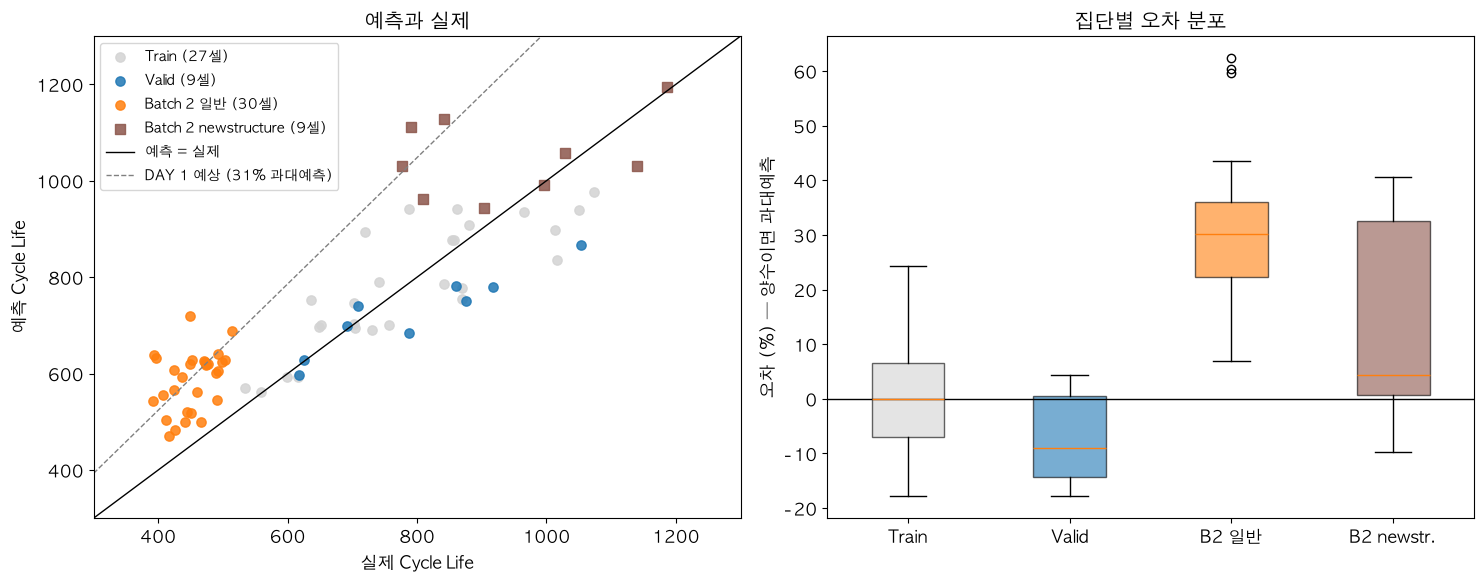

In [9]:
sets = [
    ('Train (27셀)', res_train, 'lightgray', 'o'),
    ('Valid (9셀)', res_valid, 'tab:blue', 'o'),
    ('Batch 2 일반 (30셀)', res_test[res_test['group'] == 'Batch 2 일반'], 'tab:orange', 'o'),
    ('Batch 2 newstructure (9셀)', res_test[res_test['group'] == 'Batch 2 newstructure'], 'tab:brown', 's'),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 왼쪽: 예측과 실제
ax = axes[0]
for label, r, color, marker in sets:
    ax.scatter(r['cycle_life'], r['pred'], color=color, marker=marker, s=45, alpha=0.85, label=label)
lim = [300, 1300]
ax.plot(lim, lim, color='black', linewidth=1, label='예측 = 실제')
ax.plot(lim, [x * 1.31 for x in lim], color='gray', linestyle='--', linewidth=1, label='DAY 1 예상 (31% 과대예측)')
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel('실제 Cycle Life')
ax.set_ylabel('예측 Cycle Life')
ax.set_title('예측과 실제')
ax.legend(fontsize=10)

# 오른쪽: 집단별 오차 분포
ax = axes[1]
bp = ax.boxplot([r['err_pct'].values for _, r, _, _ in sets], patch_artist=True)
ax.set_xticklabels(['Train', 'Valid', 'B2 일반', 'B2 newstr.'])
for patch, (_, _, color, _) in zip(bp['boxes'], sets):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('오차 (%) — 양수이면 과대예측')
ax.set_title('집단별 오차 분포')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'm2_pred_vs_actual.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. 추가 평가 — Batch 3

**목적**: 같은 모델을 Batch 3에 적용해, Batch 2에서 나온 편향이 모델 자체의 문제인지 시험 조건의 차이인지 확인한다.

**DAY 1에 예상한 것**
- Batch 3은 Batch 1의 직선과 어긋남이 없었다(실제/예측 0.99). 편향이 거의 없을 것이다.
- 다만 잔차의 표준편차가 0.077로 커서 셀별 오차는 Batch 1보다 클 것이다.
- Batch 3은 수명이 1,935까지 있다. 학습 범위(최대 1,074)를 넘는 긴 쪽의 오차를 따로 확인한다.

Batch 3은 원 논문에서 2차 평가에 쓴 배치다. 이 결과도 모델 선택에는 쓰지 않는다.

In [10]:
res_b3, sum_b3 = evaluate(b3, final, FINAL_COLS)

LIFE_MAX_TRAIN = train['cycle_life'].max()
inside = b3['cycle_life'] <= LIFE_MAX_TRAIN
parts = {
    'Batch 3 전체': sum_b3,
    f'수명 {int(LIFE_MAX_TRAIN)} 이하': evaluate(b3[inside], final, FINAL_COLS)[1],
    f'수명 {int(LIFE_MAX_TRAIN)} 초과': evaluate(b3[~inside], final, FINAL_COLS)[1],
}
b3_table = pd.DataFrame(parts)
print(b3_table.round(2))

print()
print('log_var 범위 — Train:', train['log_var'].min().round(2), '~', train['log_var'].max().round(2),
      '/ Batch 3:', b3['log_var'].min().round(2), '~', b3['log_var'].max().round(2))
print('Train의 log_var 최솟값보다 작은 Batch 3 셀:',
      int((b3['log_var'] < train['log_var'].min()).sum()), '/', len(b3))
print('과대예측한 셀:', int((res_b3['err_pct'] > 0).sum()), '/', len(res_b3))
print()
print('오차가 큰 5셀')
print(res_b3.reindex(res_b3['err_pct'].abs().sort_values(ascending=False).index).head(5)
      [['cell_id', 'policy', 'cycle_life', 'pred', 'err_pct']].round(1).to_string(index=False))

              Batch 3 전체  수명 1074 이하  수명 1074 초과
셀                  44.00       28.00       16.00
MAPE               12.50        9.30       18.10
편향(%)              -1.55        4.81      -11.75
편향 제거 후 MAPE       12.86        8.60       16.38

log_var 범위 — Train: -4.16 ~ -3.34 / Batch 3: -5.14 ~ -3.45
Train의 log_var 최솟값보다 작은 Batch 3 셀: 23 / 44
과대예측한 셀: 23 / 44

오차가 큰 5셀
cell_id         policy  cycle_life   pred  err_pct
  b3c38     5C(67%)-4C      1935.0 1110.2    -42.6
  b3c37 4.8C(80%)-4.8C      1390.0 1913.7     37.7
  b3c40 5.6C(19%)-4.6C       796.0 1075.1     35.1
   b3c7 4.8C(80%)-4.8C      1836.0 1226.9    -33.2
  b3c42 4.8C(80%)-4.8C      1642.0 1113.3    -32.2


**결과 해석 — Batch 3 평가**

- **Batch 3에서는 편향이 거의 없다(−1.55%).** 과대예측한 셀이 44셀 중 23셀로 절반이다. Batch 2 일반의 편향 +29.15%(39셀 중 37셀 과대예측)는 모델 자체의 문제가 아니라 그 집단의 조건에서 온 것으로 볼 수 있다.
- **MAPE는 12.50%다.** 편향을 빼도 12.86%로 달라지지 않는다. 이 배치의 오차는 집단의 치우침이 아니라 셀별로 흩어진 정도에서 나온다. EDA(Q3-6)에서 Batch 3의 잔차 표준편차가 0.077로 Batch 1(0.045)보다 컸던 것과 같다.
- **학습 범위 안에서는 원 논문 수준이다.** 수명 1,074 이하인 28셀의 MAPE는 9.30%다.
- **수명이 긴 쪽에서 오차가 커진다.** 수명 1,074 초과인 16셀은 MAPE 18.10%, 편향 −11.75%다. Hold-out에서 본 과소예측이 같은 방향으로 나타났다. Batch 1에서 가장 느린 충전 정책의 5셀이 EOL 미도달로 제외되어 장수명 구간을 학습하지 못한 것(DAY 1에 예상한 위험)과 관련된다.
- 구간을 실제 수명으로 나눴으므로, 긴 쪽에는 직선보다 위에 있는 셀이 모여 과소예측이 실제보다 크게 보인다. 수치의 크기보다 방향을 본다.
- 피처 기준으로도 학습 범위 밖이다. 44셀 중 23셀의 `log_var`가 Train의 최솟값보다 작다.
- 오차가 큰 5셀 중 3셀이 `4.8C(80%)-4.8C` 정책이다. b3c37(+37.7%)은 EDA(Q3-4)에서 ΔQ 곡선에 잡음이 있다고 본 셀이다.

| 평가 대상 | 셀 | MAPE | 편향 |
|---|---:|---:|---:|
| Valid (Batch 1 Hold-out) | 9 | 8.71% | −7.65% |
| Batch 2 일반 | 30 | 29.86% | +29.15% |
| Batch 2 `newstructure` | 9 | 16.01% | +12.46% |
| Batch 3 | 44 | 12.50% | −1.55% |

## 8. 오류 분석 — Batch 2 일반 30셀

**목적**: 집단 전체의 편향(+29.15%)과 별개로, 집단 안에서 오차가 큰 셀과 작은 셀이 무엇이 다른지 확인한다. 오차 분포에서 60% 안팎인 3셀이 따로 떨어져 있었다.

**확인할 것**
- 오차가 큰 셀과 작은 셀의 공통점 (정책, `log_var`, 수명)
- 오차가 어떤 값과 함께 움직이는가
- 이 집단 안에서 `log_var`와 수명의 직선이 모델의 직선과 같은 기울기인가

In [11]:
from scipy.stats import linregress

g = res_test[res_test['group'] == 'Batch 2 일반'].merge(b2[['cell_id', 'log_var']], on='cell_id')
show = ['cell_id', 'policy', 'cycle_life', 'pred', 'err_pct', 'log_var']

print('오차가 큰 5셀')
print(g.nlargest(5, 'err_pct')[show].round(2).to_string(index=False))
print()
print('오차가 작은 5셀')
print(g.nsmallest(5, 'err_pct')[show].round(2).to_string(index=False))
print()
print('오차와의 상관')
print(g[['log_var', 'cycle_life']].corrwith(g['err_pct']).round(2))
print()
print('정책별 평균 오차')
print(g.groupby('policy').agg(셀=('err_pct', 'size'), 평균오차=('err_pct', 'mean'),
                              log_var=('log_var', 'mean'), 수명=('cycle_life', 'mean'))
      .sort_values('평균오차', ascending=False).round(2))
print()
fit = linregress(g['log_var'], g['log_life'])
print(f'이 집단 안의 직선: 기울기 {fit.slope:.3f} (표준오차 {fit.stderr:.3f}), 모델의 기울기 {slope:.3f}')
print('수명 범위:', int(g['cycle_life'].min()), '~', int(g['cycle_life'].max()),
      '/ log_var 범위:', g['log_var'].min().round(2), '~', g['log_var'].max().round(2))

오차가 큰 5셀
cell_id          policy  cycle_life   pred  err_pct  log_var
   b2c6     3.6C(9%)-5C       393.0 638.12    62.37    -3.53
  b2c18 5.2C(50%)-4.25C       449.0 720.11    60.38    -3.71
  b2c15     3.6C(9%)-5C       396.0 632.15    59.63    -3.52
   b2c2 5.2C(50%)-4.25C       424.0 608.46    43.50    -3.46
  b2c29    5.2C(58%)-4C       452.0 628.71    39.10    -3.51

오차가 작은 5셀
cell_id         policy  cycle_life   pred  err_pct  log_var
  b2c12  4.65C(44%)-5C       466.0 498.53     6.98    -3.17
   b2c1 5.6C(26%)-4.5C       491.0 544.77    10.95    -3.30
  b2c41 5.6C(26%)-4.5C       442.0 500.03    13.13    -3.17
  b2c14   3.6C(30%)-6C       426.0 482.01    13.15    -3.12
   b2c5   3.6C(30%)-6C       416.0 471.39    13.32    -3.09

오차와의 상관
log_var      -0.72
cycle_life   -0.36
dtype: float64

정책별 평균 오차
                 셀   평균오차  log_var      수명
policy                                    
3.6C(9%)-5C      2  61.00    -3.52  394.50
5.2C(50%)-4.25C  5  40.55    -3.52  454.00
6C(60%)-3

**결과 해석 — 오류 분석**

- **이 집단 안에서는 `log_var`와 수명의 관계가 모델보다 훨씬 약하다.** 집단 안의 기울기가 −0.081(표준오차 0.038)로, 모델의 −0.296과 표준오차의 5배 넘게 차이 난다.
- **오차는 `log_var`에 따라 체계적으로 달라진다.** 오차와 `log_var`의 상관이 −0.72다. 모델은 `log_var`가 낮은 셀의 수명을 길게 예측하지만, 이 집단에서는 `log_var`가 낮아도 수명이 거의 늘지 않는다.
- 오차 60% 안팎인 3셀(b2c6, b2c18, b2c15)은 `log_var`가 −3.52~−3.71로 낮은 쪽이다. 모델은 630~720사이클을 예측했고 실제는 393~449다. 오차가 작은 5셀은 `log_var`가 −3.09~−3.30으로 높은 쪽이다.
- 충전 정책으로는 설명되지 않는다. 평균 오차가 가장 큰 정책(`3.6C(9%)-5C`, 61%)과 가장 작은 정책(`3.6C(30%)-6C`, 13%)이 모두 2단계가 더 빠른 유형이다.

**DAY 1의 예상과 비교**

| DAY 1의 예상 | 결과 |
|---|---|
| Batch 2 일반 셀에서 약 31% 과대예측 | 맞음. 편향 +29.15% |
| Batch 3은 편향이 거의 없음 | 맞음. 편향 −1.55% |
| 트리 계열은 학습 범위 밖을 예측하지 못함 | 맞음. 외삽 점검에서 확인 |
| Batch 2 일반 셀은 기울기가 같고 평행하게 이동 | **틀림.** 집단 안의 기울기는 −0.081 |

- "기울기가 같다"의 근거였던 Batch 2의 기울기(−0.328)는 일반 30셀과 `newstructure` 9셀을 합쳐 구한 값이었다. 떨어져 있는 두 집단을 이은 직선이어서 집단 안의 관계를 나타내지 않는다. EDA에서 상관계수에 대해 확인한 원칙(성격이 같은 집단 안에서 계산한다)을 기울기에는 적용하지 않았다.
- 잔차의 표준편차가 Batch 1과 같다는 것도 근거로 삼았으나, 이 집단은 수명 범위가 392~514로 좁아 기울기가 달라도 표준편차는 작게 나온다.
- 따라서 이 집단의 오차는 "평행 이동" 하나가 아니라 **위치의 이동과 관계의 약화** 두 가지로 이루어져 있다. 편향을 빼도 `log_var`에 따른 오차가 남는다.

## 9. 추가 실험 — 소수 셀 보정

**목적**: 조건이 다른 집단의 셀 몇 개의 수명을 알 때, 그것으로 편향을 보정하면 오차가 얼마나 줄어드는지 확인한다. DAY 1에 한계로 적은 "조건이 다른 셀의 데이터가 일부라도 필요하다"를 실제로 해 본다.

**이 실험은 과제의 Test 성능이 아니다.** Batch 2의 수명 일부를 사용하므로 성능 표에는 넣지 않고 따로 보고한다. Test 성능은 6단계의 26.66%다.

**방법**
- 집단에서 k개 셀을 무작위로 뽑아 보정용으로 쓴다. 이 셀들의 예측과 실제의 차이(로그 기준 평균)를 편향으로 본다.
- 나머지 셀의 예측에서 그 편향을 빼고 MAPE를 계산한다. 모델의 기울기는 그대로 두고 절편만 옮기는 것이다.
- 어떤 셀을 뽑느냐에 따라 결과가 달라지므로 1,000번 반복해 평균과 범위(하위 5%, 상위 5%)를 낸다.

**비교 대상**: 모델을 쓰지 않고 보정 셀의 평균 수명을 나머지 셀의 예측으로 쓰는 방법. 8단계에서 이 집단 안의 `log_var` 관계가 약했으므로, 모델이 이 단순한 방법보다 나은지 확인한다.

In [12]:
N_REPEAT = 1000
K_LIST = [1, 2, 3, 5, 10]


def calibration_experiment(r, k_list, n_repeat, seed):
    """보정용 k셀로 편향을 추정해 나머지 셀의 예측에서 뺀다. 무작위 추출을 반복한다."""
    rng = np.random.default_rng(seed)
    y, p = r['log_life'].values, r['pred_log'].values
    rows = []
    for k in k_list:
        model_scores, mean_scores = [], []
        for _ in range(n_repeat):
            cal = rng.choice(len(r), size=k, replace=False)
            rest = np.setdiff1d(np.arange(len(r)), cal)
            offset = (p[cal] - y[cal]).mean()
            model_scores.append(mape(y[rest], p[rest] - offset))
            mean_scores.append(mape(y[rest], np.full(len(rest), y[cal].mean())))
        rows.append({'보정 셀 수': k,
                     '모델 + 보정 MAPE': np.mean(model_scores),
                     '하위 5%': np.percentile(model_scores, 5),
                     '상위 5%': np.percentile(model_scores, 95),
                     '보정 셀 평균만 사용': np.mean(mean_scores)})
    return pd.DataFrame(rows)


for gname in ['Batch 2 일반', 'Batch 2 newstructure']:
    r = res_test[res_test['group'] == gname]
    ks = [k for k in K_LIST if k < len(r) - 2]
    print(f'--- {gname} ({len(r)}셀), 보정 전 MAPE {mape(r["log_life"], r["pred_log"]):.2f} ---')
    print(calibration_experiment(r, ks, N_REPEAT, SEED).round(2).to_string(index=False))
    print()

--- Batch 2 일반 (30셀), 보정 전 MAPE 29.86 ---


 보정 셀 수  모델 + 보정 MAPE  하위 5%  상위 5%  보정 셀 평균만 사용
      1         11.81   8.36  20.71         8.98
      2         10.54   8.20  15.61         7.87
      3          9.82   7.72  13.72         7.42
      5          9.24   7.58  11.95         7.12
     10          8.74   6.90  10.79         6.89

--- Batch 2 newstructure (9셀), 보정 전 MAPE 16.01 ---
 보정 셀 수  모델 + 보정 MAPE  하위 5%  상위 5%  보정 셀 평균만 사용
      1         19.18  15.50  29.13        19.54
      2         16.68  12.31  23.06        16.67
      3         16.04  12.12  24.28        15.89
      5         15.82  10.68  24.63        15.46



**결과 해석 — 소수 셀 보정**

**Batch 2 일반 30셀**
- **보정 셀 3개로 MAPE가 29.86%에서 9.82%로 내려간다.** 5개면 9.24%, 10개면 8.74%다.
- 보정 셀이 1개일 때는 평균 11.81%이지만 뽑힌 셀에 따라 8.36~20.71%로 불안정하다. 3개부터 상위 5%가 14% 아래로 들어온다.
- **그러나 모델 없이 보정 셀의 평균 수명만 쓰는 쪽이 더 낫다.** 3개 기준 7.42%로 모델 + 보정(9.82%)보다 2.4%p 낮고, 모든 k에서 같다.
- 8단계의 결과와 같은 결론이다. 이 집단 안에서는 `log_var`가 달라도 수명이 거의 달라지지 않으므로(기울기 −0.081), 모델이 `log_var`에 따라 예측을 다르게 하는 것이 오차가 된다.

**Batch 2 `newstructure` 9셀**
- **보정 효과가 없다.** 보정 전 16.01%, 3개로 보정 후 16.04%다. 1개로 보정하면 19.18%로 나빠진다. 이 집단의 오차는 치우침이 아니라 셀별 흩어짐이어서 절편을 옮겨도 줄지 않는다.

**정리**
- 조건이 다른 집단에 대해서는 그 집단의 셀 3~5개의 수명을 알면 오차를 10% 아래로 낮출 수 있다. 다만 이 집단처럼 수명 범위가 좁으면(392~514) 그 셀들의 평균만으로 충분하고, 모델은 더하는 것이 없다.
- 모델이 의미를 갖는 것은 수명이 넓게 퍼진 경우다. Batch 3(541~1,935)에서 모델의 MAPE는 12.50%였다. 원 논문에 따르면 학습 데이터의 평균 수명으로 예측할 때의 오차는 약 30~36%다.
- 보정에는 대상 조건의 셀을 수명이 끝날 때까지 시험한 결과가 필요하다. 초기 100사이클만으로 예측한다는 원래 목적에는 그만큼의 비용이 추가된다.

## 10. 성능 정리

**목적**: 과제의 보고 형식(Train CV / Valid Hold-out / Test / Gap 3종)으로 성능을 정리하고 저장한다.

- Train (CV): Train 27셀의 정책 단위 5-폴드 교차검증 MAPE
- Valid (Hold-out): Batch 1에서 따로 떼어 둔 9셀
- Test: Batch 2 39셀. 9단계의 보정은 반영하지 않는다.
- Test (Batch 3): 추가 평가. 과제 형식에 따라 Batch 2와 나란히 적는다.
- Target: 원 논문의 9.1%
- Gap은 표기한 순서대로 뺀 값이다. MAPE는 낮을수록 좋으므로, Gap (Valid-Test)와 Gap (Target-Test)는 음수일 때 Test의 성능이 더 나쁘다는 뜻이다.

In [13]:
TARGET = 9.1   # 원 논문의 MAPE (%)

cv_final = cv_table[(cv_table['피처'] == 'log_var') & (cv_table['모델'] == 'Linear')]['검증 폴드 MAPE'].iloc[0]
v, t = sum_valid['MAPE'], sum_test['MAPE']

t3 = sum_b3['MAPE']
# 과제의 보고 형식 (Regression, Batch 3 포함). Gap은 표기한 순서대로 뺀 값이다.
perf = pd.DataFrame([
    {'구분': 'Train (Batch 1 CV)', 'MAPE(%)': cv_final},
    {'구분': 'Valid (Batch 1 Hold-out)', 'MAPE(%)': v},
    {'구분': 'Test (Batch 2)', 'MAPE(%)': t},
    {'구분': 'Gap (Train-Valid)', 'MAPE(%)': cv_final - v},
    {'구분': 'Gap (Valid-Test)', 'MAPE(%)': v - t},
    {'구분': 'Gap (Target-Test)', 'MAPE(%)': TARGET - t},
    {'구분': 'Test (Batch 3)', 'MAPE(%)': t3},
    {'구분': 'Gap (Batch2-Batch3)', 'MAPE(%)': t - t3},
    {'구분': 'Gap (Target-Test, Batch 3)', 'MAPE(%)': TARGET - t3},
]).round(2)
perf.to_csv(os.path.join(RESULT_DIR, 'model_performance.csv'), index=False)
print(perf.to_string(index=False))

# 집단별 성능 (Gap 해석용)
by_group = pd.DataFrame({
    'Valid (Batch 1 Hold-out)': sum_valid,
    'Batch 2 일반': evaluate(b2[b2['group'] == 'Batch 2 일반'], final, FINAL_COLS)[1],
    'Batch 2 newstructure': evaluate(b2[b2['group'] == 'Batch 2 newstructure'], final, FINAL_COLS)[1],
    'Batch 3': sum_b3,
}).T.round(2)
by_group.to_csv(os.path.join(RESULT_DIR, 'performance_by_group.csv'))
print()
print(by_group)

                        구분  MAPE(%)
        Train (Batch 1 CV)     9.46
  Valid (Batch 1 Hold-out)     8.71
            Test (Batch 2)    26.66
         Gap (Train-Valid)     0.75
          Gap (Valid-Test)   -17.96
         Gap (Target-Test)   -17.56
            Test (Batch 3)    12.50
       Gap (Batch2-Batch3)    14.17
Gap (Target-Test, Batch 3)    -3.40

                             셀   MAPE  편향(%)  편향 제거 후 MAPE
Valid (Batch 1 Hold-out)   9.0   8.71  -7.65          7.74
Batch 2 일반                30.0  29.86  29.15          8.23
Batch 2 newstructure       9.0  16.01  12.46         13.93
Batch 3                   44.0  12.50  -1.55         12.86


**결과 해석 — 성능과 Gap**

**Gap (Train − Valid) = +0.75%p**
- 교차검증(9.46%)과 Hold-out(8.71%)의 차이가 폴드 간 표준편차(1.9) 안에 있다. 과적합의 신호는 없다. 피처 1개의 선형 회귀여서 학습 데이터에 과하게 맞춰질 여지가 작다.

**Gap (Valid − Test) = −17.96%p**
- 같은 배치 안에서는 8.71%인 모델이 Batch 2에서는 26.66%다. 이 차이는 Batch 2 일반 30셀의 편향(+29.15%)에서 온다. 이 집단은 휴지 시간이 약 5분으로 학습 배치(약 1분)와 다르고, 같은 `log_var`에서 수명이 더 짧다.
- 조건이 학습 배치와 비슷한 Batch 3에서는 편향이 −1.55%, MAPE가 12.50%다. 같은 모델이 조건에 따라 다르게 동작하므로, 이 Gap은 과적합이 아니라 학습 배치에 없는 조건에서 온 것이다.

**Gap (Target − Test) = −17.56%p**
- 원 논문의 9.1%와 직접 비교하기 어려운 이유가 두 가지다.
  - **모델이 다르다.** 9.1%는 피처 9개를 쓴 모델의 값이다. 이 프로젝트와 같은 구성(`log Var(ΔQ)` 1개)은 논문에서도 11.4~14.7%다.
  - **문제 설정이 다르다.** 논문은 휴지 1분인 배치와 5분인 배치를 합친 뒤 절반씩 학습과 평가로 나눴다. 학습 데이터에 평가 셀과 같은 조건의 셀이 들어 있었다. 이 과제는 휴지 1분인 배치만으로 학습해 5분인 셀을 평가한다.
- 논문에서 모델 개발 후에 만든 배치(이 프로젝트의 Batch 3)로 비교하면, 논문의 같은 모델이 11.4%이고 이 프로젝트가 12.50%다.

**Gap (Batch 2 − Batch 3) = +14.17%p**
- 두 평가 배치의 차이가 크다. 피처가 학습 배치에 과적합된 것은 아니다. 피처와 모델은 Batch 1만 보고 정했고, 학습에 쓰지 않은 Batch 3에서 편향이 −1.55%다. Batch 3 기준 Gap (Target − Test)는 −3.40%p다.
- 차이는 Batch 2 일반 30셀에서만 나온다. 이 집단은 휴지 시간이 약 5분이고, Batch 1은 약 1분, Batch 3과 `newstructure` 셀은 약 10초다. 조건이 Batch 1과 크게 다른 집단에서만 `log_var`와 수명의 관계가 달라졌다.

**오차의 구성**
- Batch 2 일반: 편향 +29.15%, 편향 제거 후 8.23%. 오차의 대부분이 집단 전체의 치우침이다. 다만 8단계에서 확인했듯 집단 안의 관계도 약해져 있어 평행 이동만은 아니다.
- Batch 2 `newstructure`: 편향 +12.46%, 편향 제거 후 13.93%. 치우침보다 흩어짐이 크다.
- Batch 3: 편향 −1.55%, 편향 제거 후 12.86%. 치우침은 없고, 학습 범위(최대 1,074)를 넘는 장수명 구간에서 과소예측한다.
- 편향 제거 후 MAPE는 평가 배치의 실제 수명으로 계산한 값이므로 모델의 성능이 아니다. 오차의 원인을 나누어 보기 위한 값이다.

**결론**
- 모델의 Test 성능은 MAPE 26.66%로 목표(9.1%)에 미치지 못한다.
- 원인은 모델의 복잡도가 아니라 학습 데이터의 범위다. Batch 1에는 시험 조건의 변동이 없어, 조건이 달라질 때 수명이 어떻게 변하는지 배울 수 없다. 모델이나 피처를 바꿔서 줄일 수 있는 오차가 아니다.
- 조건이 다른 대상에 적용하려면 그 조건의 셀 데이터가 학습 또는 보정에 포함되어야 한다(9단계).